In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyekfmm as fmm
import os
import seaborn as sns
from matplotlib import gridspec

np.random.seed(0)
import sys
print(sys.path)

# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

result_path = "./result/figs/marmousi/"
os.makedirs(result_path, exist_ok=True)

['', '/opt/madagascar/lib/python3.10/site-packages', '/home/g202321530/anaconda3/envs/pytorch/lib/python312.zip', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12/lib-dynload', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12/site-packages']


Velocity model loaded. Shape: (240, 737)


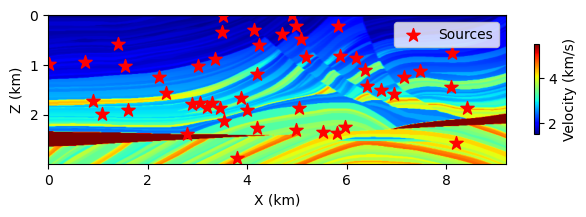

Final shapes:
T0_data_all: (50, 240, 737)
T_data_all: (50, 240, 737)
vel_data_all: (50, 240, 737)
src_data_all: (50, 240, 737)
Tau_data_all: (50, 240, 737)


In [2]:
# Hyperparameters
n_sources = 50  # Number of sources
nz, nx = 240, 737  # Grid dimensions
dx, dz = 0.0125, 0.0125  # Grid spacing in km

# Initialize data containers
T0_data_all = np.zeros((n_sources, nz, nx), dtype='float32')
T_data_all = np.zeros((n_sources, nz, nx), dtype='float32')
vel_data_all = np.zeros((n_sources, nz, nx), dtype='float32')
src_data_all = np.zeros((n_sources, nz, nx), dtype='float32')

# Load velocity model
try:
    with open('./vel_model/marmousi/marmvz.bin', 'rb') as fd:
        velzz = np.fromfile(fd, dtype=np.float32).reshape([nz, nx], order='F')  # [z, x]
    velz = velzz / 1000  # Convert velocity to km/s
    print(f"Velocity model loaded. Shape: {velz.shape}")
except FileNotFoundError:
    print("Error: Velocity model file not found. Using random data for debugging.")
    velz = np.random.rand(nz, nx) * 3 + 1  # Random velocity between 1 and 4 km/s

# Generate random source points
np.random.seed(20252025)  # For reproducibility
source_locs = np.random.randint(0, [nx, nz], size=(n_sources, 2)).astype('float32')  # [x, z]

# Convert to physical coordinates (km)
source_locs_physical = source_locs * [dx, dz]



np.random.seed(202506)  # For reproducibility
source_locs1 = np.random.randint(0, [nx, nz], size=(100, 2)).astype('float32')  # [x, z]
# Convert to physical coordinates (km)
source_locs_physical1 = source_locs1 * [dx, dz]

# Visualization of velocity model with source locations
plt.figure()
plt.imshow(velz, extent=[0, (nx-1)*dx, (nz-1)*dz, 0], cmap='jet')
plt.colorbar(shrink=0.2, label='Velocity (km/s)')
plt.scatter(source_locs_physical[:, 0], source_locs_physical[:, 1], c='red', marker='*', s=100, label='Sources')
plt.xlabel('X (km)')
plt.ylabel('Z (km)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Calculate traveltime fields for each source
for src_idx, (sx, sz) in enumerate(source_locs):
    sx, sz = int(sx), int(sz)  # Convert to integer indices
    src_physical = np.array([sz * dz, 0, sx * dx], dtype='float32')  # [x, y, z] in km

    # Populate velocity and source data
    vel_data_all[src_idx] = velz
    src_data_all[src_idx, sz, sx] = 1

    # Heterogeneous velocity computation
    velz_1d = velz.transpose().flatten(order='F')  # [z, x] -> [x, z]
    t = fmm.eikonal(
        velz_1d,
        xyz=src_physical,  # [x, y, z]
        ax=[0, dz, nz],  # x-axis
        ay=[0, dx, 1],   # y-axis (not used in 2D)
        az=[0, dx, nx],  # z-axis
        order=2
    )
    T_data_all[src_idx] = t.reshape(nz, nx, order='F')  # Reshape to [z, x]

    # Homogeneous velocity computation
    vel_homo = velz[sz, sx] * np.ones([nz * nx], dtype='float32')
    t1 = fmm.eikonal(
        vel_homo,
        xyz=src_physical,  # [x, y, z]
        ax=[0, dz, nz],  # x-axis
        ay=[0, dx, 1],   # y-axis (not used in 2D)
        az=[0, dx, nx],  # z-axis
        order=2
    )
    T0_data_all[src_idx] = t1.reshape(nz, nx, order='F')  # Reshape to [z, x]

# Compute Tau data
Tau_data_all = T_data_all - T0_data_all  # Shape: (n_sources, nz, nx)

# Print final shapes
print("Final shapes:")
print(f"T0_data_all: {T0_data_all.shape}")
print(f"T_data_all: {T_data_all.shape}")
print(f"vel_data_all: {vel_data_all.shape}")
print(f"src_data_all: {src_data_all.shape}")
print(f"Tau_data_all: {Tau_data_all.shape}")

In [3]:
################################################################
# Load Prediction
################################################################
epochs = 2000
FNO_tau = np.load(f'./prediction/Vanilla_FNO/Marmousi/Vanilla_FNO_Pred_Tau_src50_ep{epochs}.npy')
KAGFNO_tau = np.load(f'./prediction/KAN_FNO/Marmousi/KAGFNO_Pred_Tau_src50_ep{epochs}.npy')

KAGFNO_tau.shape

(50, 240, 737, 1)

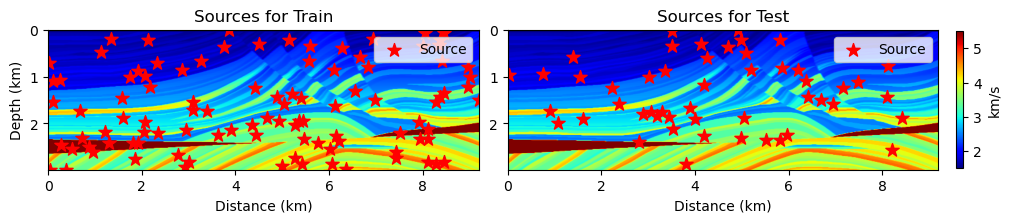

In [4]:
# Create figure and subplots with shared colorbar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), 
                              constrained_layout=True, 
                              gridspec_kw={'width_ratios': [1, 1]})  # Equal width

# Subplot 1: Velocity model with sources for train
im1 = ax1.imshow(velz, extent=[0, (nx-1)*dx, (nz-1)*dz, 0], 
                cmap='jet', aspect='equal')
ax1.scatter(source_locs_physical1[:, 0], source_locs_physical1[:, 1], 
           c='red', marker='*', s=100, label='Source')
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel('Depth (km)')
ax1.set_title('Sources for Train', fontsize=12)
ax1.legend(loc='upper right')

# Subplot 2: Velocity model with sources for test
im2 = ax2.imshow(velz, extent=[0, (nx-1)*dx, (nz-1)*dz, 0], 
                cmap='jet', aspect='equal')
ax2.scatter(source_locs_physical[:, 0], source_locs_physical[:, 1], 
           c='red', marker='*', s=100, label='Source')
ax2.set_xlabel('Distance (km)')
# ax2.set_ylabel('Depth (km)')  # Commented out as in original
ax2.set_title('Sources for Test', fontsize=12)
ax2.legend(loc='upper right')

# Add single colorbar
cbar = fig.colorbar(im1, ax=[ax1, ax2], shrink=0.35, label='km/s', 
                   pad=0.02)  # Adjust shrink and pad as needed

# Ensure equal aspect ratios and tight layout
ax1.set_aspect('equal')
ax2.set_aspect('equal')

# plt.savefig(f'{result_path}marmousi_src_distribution_FNO_and_KAGFNO_ep{epochs}.png', bbox_inches='tight', dpi=300)
# plt.savefig(f'{result_path}marmousi_src_distribution_FNO_and_KAGFNO_ep{epochs}.pdf', bbox_inches='tight', dpi=300)
plt.show()

MSE Statistics (across 50 sources):
Mean FNO: 6.203e-04	KAGFNO: 3.118e-04
Std FNO: 5.130e-04	KAGFNO: 2.743e-04
Min FNO: 1.080e-04	KAGFNO: 3.456e-05
Max FNO: 2.186e-03	KAGFNO: 1.584e-03


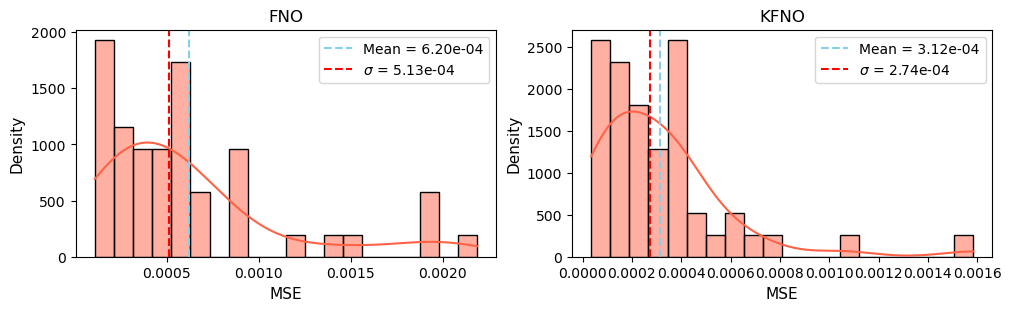

In [5]:
# Calculate MSE per source
mse_FNO = np.mean((Tau_data_all - FNO_tau[:, :, :, 0]) ** 2, axis=(1, 2))
mse_KAGFNO = np.mean((Tau_data_all - KAGFNO_tau[:, :, :, 0]) ** 2, axis=(1, 2))

# Print some statistics
print(f"MSE Statistics (across 50 sources):")
print(f"Mean FNO: {np.mean(mse_FNO):.3e}\tKAGFNO: {np.mean(mse_KAGFNO):.3e}")
print(f"Std FNO: {np.std(mse_FNO):.3e}\tKAGFNO: {np.std(mse_KAGFNO):.3e}")
print(f"Min FNO: {np.min(mse_FNO):.3e}\tKAGFNO: {np.min(mse_KAGFNO):.3e}")
print(f"Max FNO: {np.max(mse_FNO):.3e}\tKAGFNO: {np.max(mse_KAGFNO):.3e}")

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3), 
                              constrained_layout=True, 
                              gridspec_kw={'width_ratios': [1, 1]})  # Equal width

# Subplot 1: MSE histogram for FNO
sns.histplot(data=mse_FNO, bins=20, kde=True, color='tomato', 
             stat='density', alpha=0.5, ax=ax1)
ax1.axvline(np.mean(mse_FNO), color='skyblue', linestyle='--', 
            label=f'Mean = {np.mean(mse_FNO):.2e}')
ax1.axvline(np.std(mse_FNO), color='red', linestyle='--', 
            label=f'$\\sigma$ = {np.std(mse_FNO):.2e}')
ax1.set_xlabel('MSE', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('FNO', fontsize=12)
ax1.legend(fontsize=10)

# Subplot 2: MSE histogram for KAGFNO
sns.histplot(data=mse_KAGFNO, bins=20, kde=True, color='tomato', 
             stat='density', alpha=0.5, ax=ax2)
ax2.axvline(np.mean(mse_KAGFNO), color='skyblue', linestyle='--', 
            label=f'Mean = {np.mean(mse_KAGFNO):.2e}')
ax2.axvline(np.std(mse_KAGFNO), color='red', linestyle='--', 
            label=f'$\\sigma$ = {np.std(mse_KAGFNO):.2e}')
ax2.set_xlabel('MSE', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('KFNO', fontsize=12)
ax2.legend(fontsize=10)

# plt.savefig(f'{result_path}marmousi_MSE_distribution_FNO_and_KAGFNO_ep{epochs}.png', bbox_inches='tight', dpi=300)
# plt.savefig(f'{result_path}marmousi_MSE_distribution_FNO_and_KAGFNO_ep{epochs}.pdf', bbox_inches='tight', dpi=300)
plt.show()

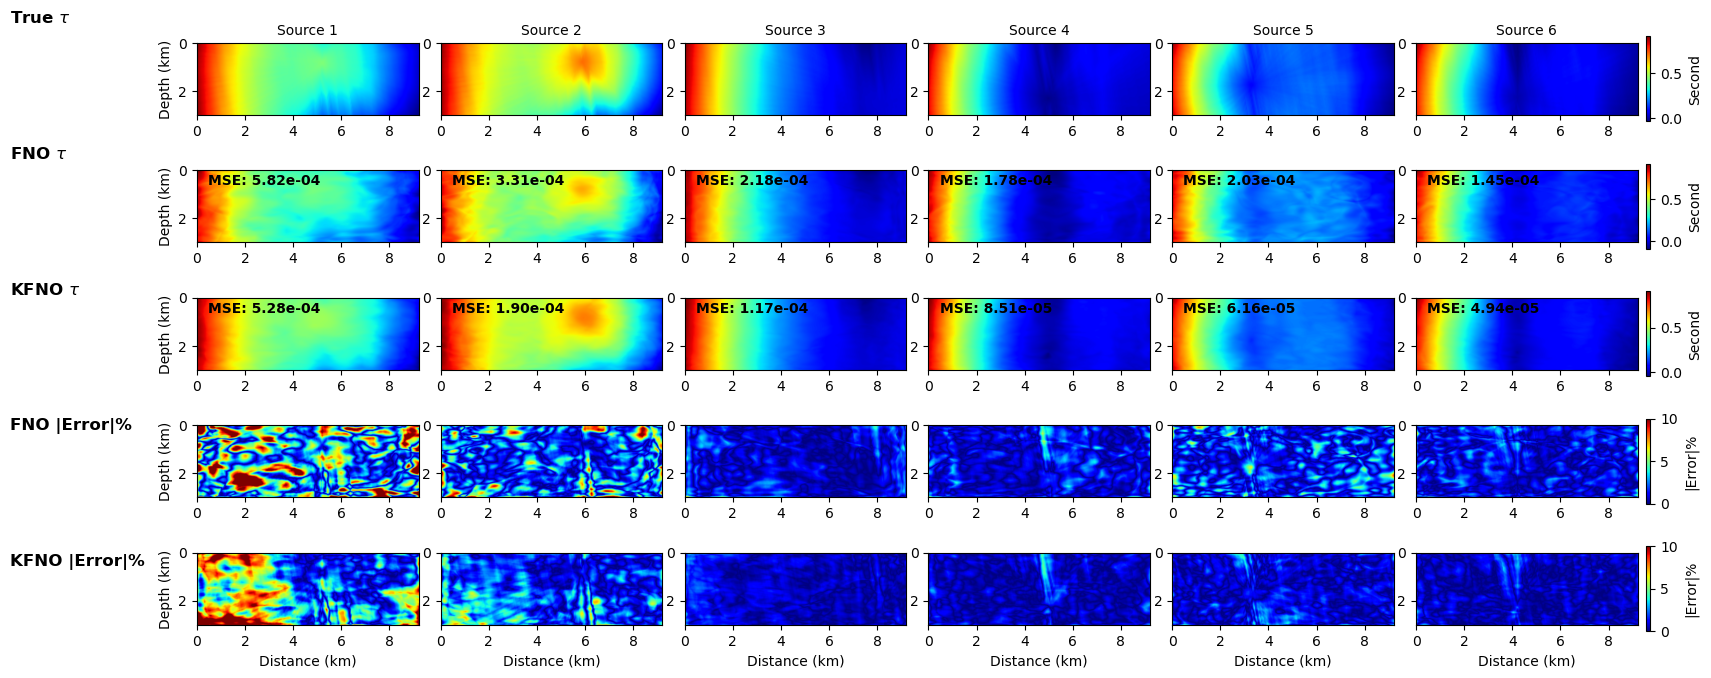

In [12]:
shrink=0.8
index=6
# Create figure and axes
fig, axes = plt.subplots(5, 6, figsize=(22, 8))
plt.subplots_adjust(wspace=0.1, hspace=0.2)

# First pass: Compute global min/max and max_ape
vmin_true_pred = float('inf')
vmax_true_pred = float('-inf')
max_ape = 0
for i in range(6):
    true_data = Tau_data_all[i+index, :, :]
    pred_FNO = FNO_tau[i+index, :, :, 0]
    pred_KFNO = KAGFNO_tau[i+index, :, :, 0]
    vmin_true_pred = min(vmin_true_pred, true_data.min(), pred_FNO.min(), pred_KFNO.min())
    vmax_true_pred = max(vmax_true_pred, true_data.max(), pred_FNO.max(), pred_KFNO.max())
    max_true = np.max(np.abs(true_data))
    if max_true > 0:
        ape_FNO = (np.abs(pred_FNO - true_data) / max_true) * 100
        ape_KFNO = (np.abs(pred_KFNO - true_data) / max_true) * 100
        max_ape = max(max_ape, np.max(ape_FNO), np.max(ape_KFNO))

# Second pass: Plotting
for i in range(6):
    true_data = Tau_data_all[i+index, :, :]
    pred_FNO = FNO_tau[i+index, :, :, 0]
    pred_KFNO = KAGFNO_tau[i+index, :, :, 0]
    max_true = np.max(np.abs(true_data))  # Calculate max_true for each sample

    # Calculate MSE for FNO and KFNO
    mse_FNO = np.mean((pred_FNO - true_data) ** 2)
    mse_KFNO = np.mean((pred_KFNO - true_data) ** 2)

    # Ground Truth
    im0 = axes[0, i].imshow(true_data, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[0, i].set_title(f'Source {i+1}', fontsize=10)
    # axes[0, i].set_xticks([0, nx*dx/2, nx*dx])
    # axes[0, i].set_yticks([0, nz*dz/2, nz*dz])
    
    # FNO Prediction
    im1 = axes[1, i].imshow(pred_FNO, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    # axes[1, i].set_xticks([0, nx*dx/2, nx*dx])
    # axes[1, i].set_yticks([0, nz*dz/2, nz*dz])
    # Add MSE text for FNO
    axes[1, i].text(0.05, 0.95, f'MSE: {mse_FNO:.2e}', transform=axes[1, i].transAxes, 
                    fontsize=10, color='black', fontweight='bold', verticalalignment='top')

    # KFNO Prediction
    im2 = axes[2, i].imshow(pred_KFNO, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    # axes[2, i].set_xticks([0, nx*dx/2, nx*dx])
    # axes[2, i].set_yticks([0, nz*dz/2, nz*dz])
    # Add MSE text for KFNO
    axes[2, i].text(0.05, 0.95, f'MSE: {mse_KFNO:.2e}', transform=axes[2, i].transAxes, 
                    fontsize=10, color='black', fontweight='bold', verticalalignment='top')
    
    # APE for FNO
    ape_FNO = (np.abs(pred_FNO - true_data) / max_true) * 100 if max_true > 0 else np.zeros_like(true_data)
    im3 = axes[3, i].imshow(ape_FNO, extent=[0, nx*dx, nz*dz, 0], cmap='jet', vmin=0, vmax=10)
    # axes[3, i].set_xticks([0, nx*dx/2, nx*dx])
    # axes[3, i].set_yticks([0, nz*dz/2, nz*dz])

    # APE for KFNO
    ape_KFNO = (np.abs(pred_KFNO - true_data) / max_true) * 100 if max_true > 0 else np.zeros_like(true_data)
    im4 = axes[4, i].imshow(ape_KFNO, extent=[0, nx*dx, nz*dz, 0], cmap='jet', vmin=0, vmax=10)
    axes[4, i].set_xlabel('Distance (km)')
    # axes[4, i].set_xticks([0, nx*dx/2, nx*dx])
    # axes[4, i].set_yticks([0, nz*dz/2, nz*dz])
    
    # Y-labels for first column
    if i == 0:
        for j in range(5):
            axes[j, i].set_ylabel('Depth (km)')

# Add row titles
row_titles = ['True $\\tau$', 'FNO $\\tau$', 'KFNO $\\tau$', 'FNO |Error|%', 'KFNO |Error|%']
for j, title in enumerate(row_titles):
    fig.text(0.04, 0.89 - j * 0.17, title, va='center', ha='left', fontsize=12, fontweight='bold')

# Add single colorbars per row
cbar0 = fig.colorbar(im0, ax=axes[0, :], shrink=shrink, pad=0.005, location='right')
cbar0.set_label('Second')
cbar1 = fig.colorbar(im1, ax=axes[1, :], shrink=shrink, pad=0.005, location='right')
cbar1.set_label('Second')
cbar2 = fig.colorbar(im2, ax=axes[2, :], shrink=shrink, pad=0.005, location='right')
cbar2.set_label('Second')
cbar3 = fig.colorbar(im3, ax=axes[3, :], shrink=shrink, pad=0.005, location='right')
cbar3.set_label('|Error|%')
cbar4 = fig.colorbar(im4, ax=axes[4, :], shrink=shrink, pad=0.005, location='right')
cbar4.set_label('|Error|%')

# plt.savefig(f'{result_path}marmousi_comparison_FNO_and_KAGFNO_tau_ep{epochs}.png', bbox_inches='tight', dpi=300)
# plt.savefig(f'{result_path}marmousi_comparison_FNO_and_KAGFNO_tau_ep{epochs}.pdf', bbox_inches='tight', dpi=300)
plt.show()

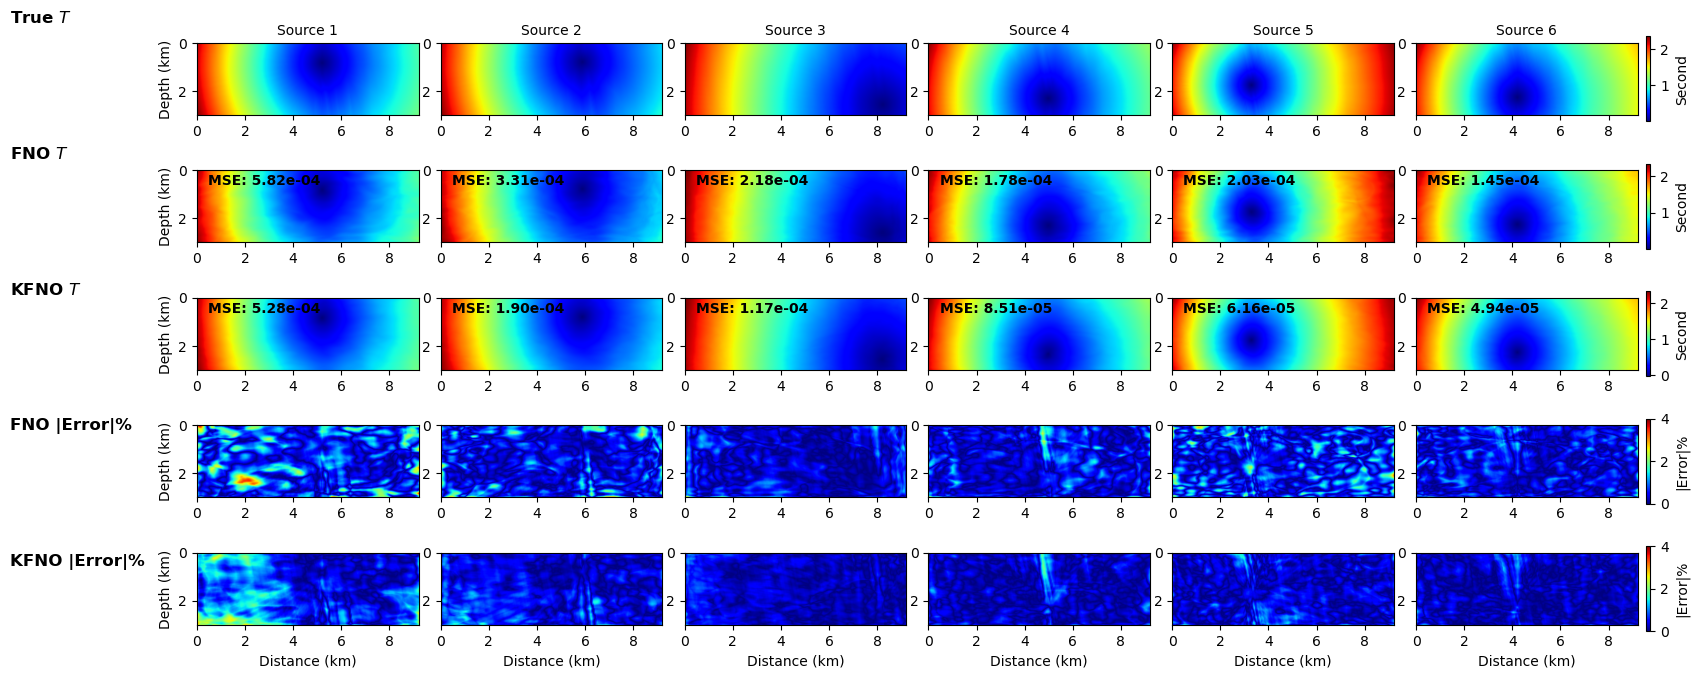

In [13]:
# Create figure and axes
fig, axes = plt.subplots(5, 6, figsize=(22, 8))
plt.subplots_adjust(wspace=0.1, hspace=0.2)

# First pass: Compute global min/max and max_ape
vmin_true_pred = float('inf')
vmax_true_pred = float('-inf')
max_ape = 0
for i in range(6):
    true_data = Tau_data_all[i+index, :, :] + T0_data_all[i+index, :, :]
    pred_FNO = FNO_tau[i+index, :, :, 0] + T0_data_all[i+index, :, :]
    pred_KFNO = KAGFNO_tau[i+index, :, :, 0] + T0_data_all[i+index, :, :]
    vmin_true_pred = min(vmin_true_pred, true_data.min(), pred_FNO.min(), pred_KFNO.min())
    vmax_true_pred = max(vmax_true_pred, true_data.max(), pred_FNO.max(), pred_KFNO.max())
    max_true = np.max(np.abs(true_data))
    if max_true > 0:
        ape_FNO = (np.abs(pred_FNO - true_data) / max_true) * 100
        ape_KFNO = (np.abs(pred_KFNO - true_data) / max_true) * 100
        max_ape = max(max_ape, np.max(ape_FNO), np.max(ape_KFNO))

# Second pass: Plotting
for i in range(6):
    true_data = Tau_data_all[i+index, :, :] + T0_data_all[i+index, :, :]
    pred_FNO = FNO_tau[i+index, :, :, 0] + T0_data_all[i+index, :, :]
    pred_KFNO = KAGFNO_tau[i+index, :, :, 0] + T0_data_all[i+index, :, :]
    max_true = np.max(np.abs(true_data))  # Calculate max_true for each sample

    # Calculate MSE for FNO and KFNO
    mse_FNO = np.mean((pred_FNO - true_data) ** 2)
    mse_KFNO = np.mean((pred_KFNO - true_data) ** 2)

    # Ground Truth
    im0 = axes[0, i].imshow(true_data, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[0, i].set_title(f'Source {i+1}', fontsize=10)
    # axes[0, i].set_xticks([0, nx*dx/2, nx*dx])
    # axes[0, i].set_yticks([0, nz*dz/2, nz*dz])
    
    # FNO Prediction
    im1 = axes[1, i].imshow(pred_FNO, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    # axes[1, i].set_xticks([0, nx*dx/2, nx*dx])
    # axes[1, i].set_yticks([0, nz*dz/2, nz*dz])
    # Add MSE text for FNO
    axes[1, i].text(0.05, 0.95, f'MSE: {mse_FNO:.2e}', transform=axes[1, i].transAxes, 
                    fontsize=10, color='black', fontweight='bold', verticalalignment='top')

    # KFNO Prediction
    im2 = axes[2, i].imshow(pred_KFNO, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    # axes[2, i].set_xticks([0, nx*dx/2, nx*dx])
    # axes[2, i].set_yticks([0, nz*dz/2, nz*dz])
    # Add MSE text for KFNO
    axes[2, i].text(0.05, 0.95, f'MSE: {mse_KFNO:.2e}', transform=axes[2, i].transAxes, 
                    fontsize=10, color='black', fontweight='bold', verticalalignment='top')
    
    # APE for FNO
    ape_FNO = (np.abs(pred_FNO - true_data) / max_true) * 100 if max_true > 0 else np.zeros_like(true_data)
    im3 = axes[3, i].imshow(ape_FNO, extent=[0, nx*dx, nz*dz, 0], cmap='jet', vmin=0, vmax=4)
    # axes[3, i].set_xticks([0, nx*dx/2, nx*dx])
    # axes[3, i].set_yticks([0, nz*dz/2, nz*dz])

    # APE for KFNO
    ape_KFNO = (np.abs(pred_KFNO - true_data) / max_true) * 100 if max_true > 0 else np.zeros_like(true_data)
    im4 = axes[4, i].imshow(ape_KFNO, extent=[0, nx*dx, nz*dz, 0], cmap='jet', vmin=0, vmax=4)
    axes[4, i].set_xlabel('Distance (km)')
    # axes[4, i].set_xticks([0, nx*dx/2, nx*dx])
    # axes[4, i].set_yticks([0, nz*dz/2, nz*dz])
    
    # Y-labels for first column
    if i == 0:
        for j in range(5):
            axes[j, i].set_ylabel('Depth (km)')

# Add row titles
row_titles = ['True $T$', 'FNO $T$', 'KFNO $T$', 'FNO |Error|%', 'KFNO |Error|%']
for j, title in enumerate(row_titles):
    fig.text(0.04, 0.89 - j * 0.17, title, va='center', ha='left', fontsize=12, fontweight='bold')

# Add single colorbars per row
cbar0 = fig.colorbar(im0, ax=axes[0, :], shrink=shrink, pad=0.005, location='right')
cbar0.set_label('Second')
cbar1 = fig.colorbar(im1, ax=axes[1, :], shrink=shrink, pad=0.005, location='right')
cbar1.set_label('Second')
cbar2 = fig.colorbar(im2, ax=axes[2, :], shrink=shrink, pad=0.005, location='right')
cbar2.set_label('Second')
cbar3 = fig.colorbar(im3, ax=axes[3, :], shrink=shrink, pad=0.005, location='right')
cbar3.set_label('|Error|%')
cbar4 = fig.colorbar(im4, ax=axes[4, :], shrink=shrink, pad=0.005, location='right')
cbar4.set_label('|Error|%')

# plt.savefig(f'{result_path}marmousi_comparison_FNO_and_KAGFNO_T_ep{epochs}.png', bbox_inches='tight', dpi=300)
# plt.savefig(f'{result_path}marmousi_comparison_FNO_and_KAGFNO_T_ep{epochs}.pdf', bbox_inches='tight', dpi=300)
plt.show()